In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('flights_sample_3m.csv')
print(f"Shape: {df.shape}")
print(df.head())

Shape: (3000000, 32)
      FL_DATE                AIRLINE                AIRLINE_DOT AIRLINE_CODE  \
0  2019-01-09  United Air Lines Inc.  United Air Lines Inc.: UA           UA   
1  2022-11-19   Delta Air Lines Inc.   Delta Air Lines Inc.: DL           DL   
2  2022-07-22  United Air Lines Inc.  United Air Lines Inc.: UA           UA   
3  2023-03-06   Delta Air Lines Inc.   Delta Air Lines Inc.: DL           DL   
4  2020-02-23       Spirit Air Lines       Spirit Air Lines: NK           NK   

   DOT_CODE  FL_NUMBER ORIGIN          ORIGIN_CITY DEST  \
0     19977       1562    FLL  Fort Lauderdale, FL  EWR   
1     19790       1149    MSP      Minneapolis, MN  SEA   
2     19977        459    DEN           Denver, CO  MSP   
3     19790       2295    MSP      Minneapolis, MN  SFO   
4     20416        407    MCO          Orlando, FL  DFW   

               DEST_CITY  ...  DIVERTED  CRS_ELAPSED_TIME  ELAPSED_TIME  \
0             Newark, NJ  ...       0.0             186.0         17

In [2]:
print(df.isnull().sum())

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE          2920860
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER          2466137
DELAY_DUE_WEATHER   

In [3]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,...,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


In [4]:
df_ml = df.copy()

df_ml['IS_CANCELLED'] = df_ml['CANCELLATION_CODE'].notna().astype(int)

delay_cols = ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
              'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']
df_ml[delay_cols] = df_ml[delay_cols].fillna(0)

print(df_ml.isnull().sum())

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE          2920860
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER                0
DELAY_DUE_WEATHER   

In [5]:
core_cols = ['AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'DEST',
             'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CANCELLED', 'DIVERTED', 'DISTANCE']
df_ml = df_ml.dropna(subset=core_cols)
df_ml = df_ml.dropna(subset=['CRS_ELAPSED_TIME'])

df_ml = df_ml[(df_ml['CANCELLED'] == 0) & (df_ml['DIVERTED'] == 0)]
df_ml = df_ml.dropna(subset=['ARR_DELAY', 'DEP_DELAY', 'TAXI_OUT', 'AIR_TIME',
                              'ELAPSED_TIME', 'ARR_TIME', 'TAXI_IN', 'WHEELS_ON'])

print(f"Remaining rows: {df_ml.shape[0]:,}")

Remaining rows: 2,913,802


In [6]:
drop_cols = ['CANCELLATION_CODE', 'CANCELLED', 'DIVERTED', 'IS_CANCELLED',
             'AIRLINE_DOT', 'AIRLINE']
df_ml = df_ml.drop(columns=drop_cols)

print(f"Shape: {df_ml.shape}")
print(df_ml.isnull().sum())

Shape: (2913802, 27)
FL_DATE                    0
AIRLINE_CODE               0
DOT_CODE                   0
FL_NUMBER                  0
ORIGIN                     0
ORIGIN_CITY                0
DEST                       0
DEST_CITY                  0
CRS_DEP_TIME               0
DEP_TIME                   0
DEP_DELAY                  0
TAXI_OUT                   0
WHEELS_OFF                 0
WHEELS_ON                  0
TAXI_IN                    0
CRS_ARR_TIME               0
ARR_TIME                   0
ARR_DELAY                  0
CRS_ELAPSED_TIME           0
ELAPSED_TIME               0
AIR_TIME                   0
DISTANCE                   0
DELAY_DUE_CARRIER          0
DELAY_DUE_WEATHER          0
DELAY_DUE_NAS              0
DELAY_DUE_SECURITY         0
DELAY_DUE_LATE_AIRCRAFT    0
dtype: int64


In [7]:
df_ml['FL_DATE'] = pd.to_datetime(df_ml['FL_DATE'])
df_ml['MONTH'] = df_ml['FL_DATE'].dt.month
df_ml['DAY_OF_WEEK'] = df_ml['FL_DATE'].dt.dayofweek
df_ml['DAY_OF_MONTH'] = df_ml['FL_DATE'].dt.day
df_ml['YEAR'] = df_ml['FL_DATE'].dt.year
df_ml['IS_WEEKEND'] = (df_ml['DAY_OF_WEEK'] >= 5).astype(int)
df_ml['DEP_HOUR'] = (df_ml['CRS_DEP_TIME'] // 100).astype(int)
df_ml['ARR_HOUR'] = (df_ml['CRS_ARR_TIME'] // 100).astype(int)

# Target
df_ml['IS_DELAYED'] = (df_ml['ARR_DELAY'] > 15).astype(int)

print(f"Target distribution:")
print(df_ml['IS_DELAYED'].value_counts(normalize=True).round(3))

Target distribution:
IS_DELAYED
0    0.823
1    0.177
Name: proportion, dtype: float64


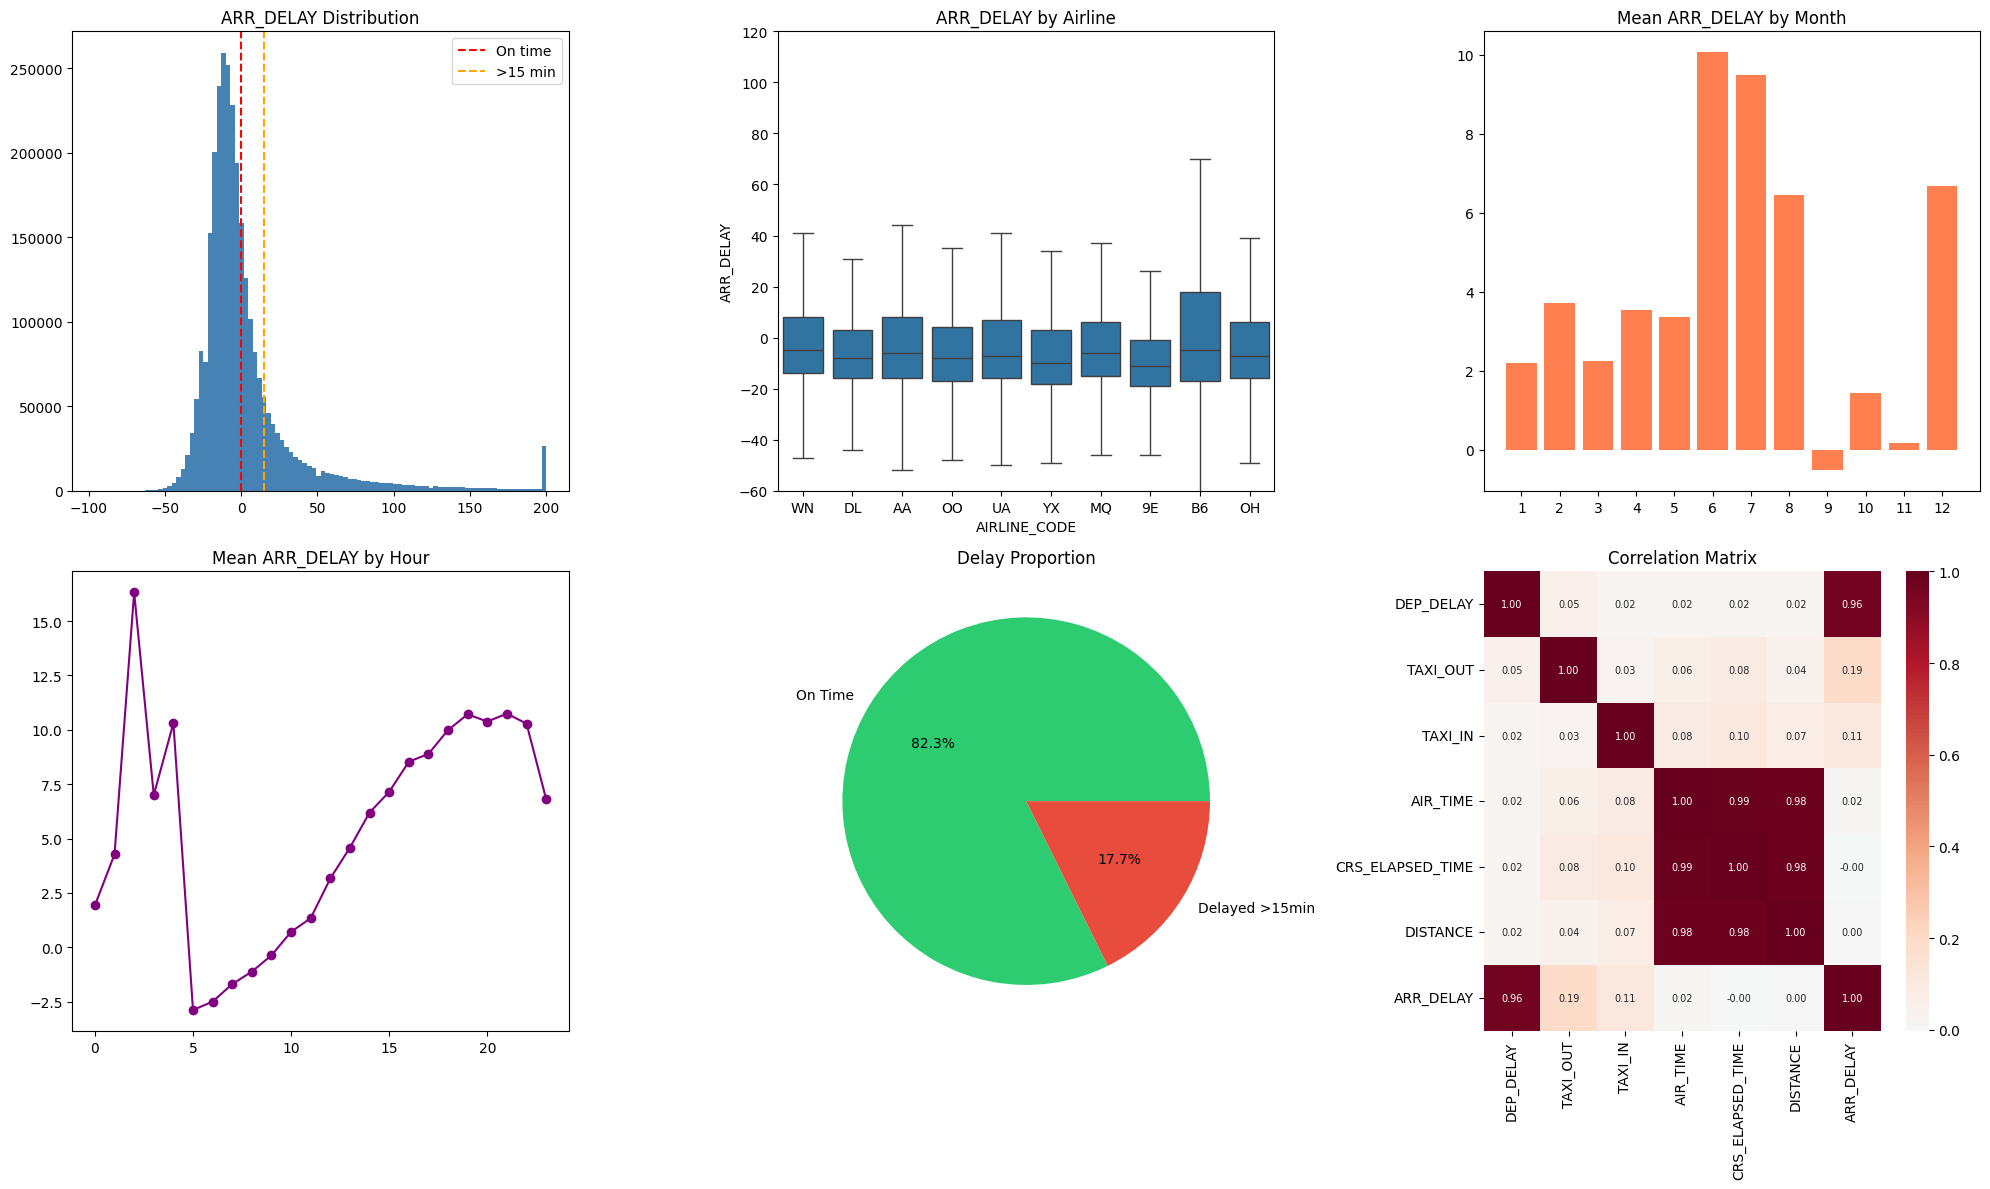

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes[0,0].hist(df_ml['ARR_DELAY'].clip(-100, 200), bins=100, color='steelblue', edgecolor='none')
axes[0,0].axvline(x=0, color='red', linestyle='--', label='On time')
axes[0,0].axvline(x=15, color='orange', linestyle='--', label='>15 min')
axes[0,0].set_title('ARR_DELAY Distribution')
axes[0,0].legend()

top_airlines = df_ml['AIRLINE_CODE'].value_counts().head(10).index
sns.boxplot(data=df_ml[df_ml['AIRLINE_CODE'].isin(top_airlines)],
            x='AIRLINE_CODE', y='ARR_DELAY', order=top_airlines,
            ax=axes[0,1], showfliers=False)
axes[0,1].set_title('ARR_DELAY by Airline')
axes[0,1].set_ylim(-60, 120)

monthly = df_ml.groupby('MONTH')['ARR_DELAY'].mean()
axes[0,2].bar(monthly.index, monthly.values, color='coral')
axes[0,2].set_title('Mean ARR_DELAY by Month')
axes[0,2].set_xticks(range(1, 13))

hourly = df_ml.groupby('DEP_HOUR')['ARR_DELAY'].mean()
axes[1,0].plot(hourly.index, hourly.values, marker='o', color='purple')
axes[1,0].set_title('Mean ARR_DELAY by Hour')

delayed = (df_ml['ARR_DELAY'] > 15).sum()
on_time = (df_ml['ARR_DELAY'] <= 15).sum()
axes[1,1].pie([on_time, delayed], labels=['On Time', 'Delayed >15min'],
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1,1].set_title('Delay Proportion')

numeric_cols = ['DEP_DELAY', 'TAXI_OUT', 'TAXI_IN', 'AIR_TIME',
                'CRS_ELAPSED_TIME', 'DISTANCE', 'ARR_DELAY']
sns.heatmap(df_ml[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[1,2], annot_kws={'size': 7})
axes[1,2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [9]:
# Route delay rate
df_ml['ROUTE'] = df_ml['ORIGIN'] + '_' + df_ml['DEST']
route_delay = df_ml.groupby('ROUTE')['IS_DELAYED'].mean()
df_ml['ROUTE_DELAY_RATE'] = df_ml['ROUTE'].map(route_delay)

# Airline delay rate
airline_delay = df_ml.groupby('AIRLINE_CODE')['IS_DELAYED'].mean()
df_ml['AIRLINE_DELAY_RATE'] = df_ml['AIRLINE_CODE'].map(airline_delay)

# Airport delay rates
origin_delay = df_ml.groupby('ORIGIN')['IS_DELAYED'].mean()
df_ml['ORIGIN_DELAY_RATE'] = df_ml['ORIGIN'].map(origin_delay)

dest_delay = df_ml.groupby('DEST')['IS_DELAYED'].mean()
df_ml['DEST_DELAY_RATE'] = df_ml['DEST'].map(dest_delay)

# Busy airport flag
busy = df_ml['ORIGIN'].value_counts().head(20).index
df_ml['IS_BUSY_ORIGIN'] = df_ml['ORIGIN'].isin(busy).astype(int)

# Season
df_ml['SEASON'] = df_ml['MONTH'].map({
    12:1, 1:1, 2:1, 3:2, 4:2, 5:2,
    6:3, 7:3, 8:3, 9:4, 10:4, 11:4
})

# Time block
df_ml['TIME_BLOCK'] = pd.cut(df_ml['DEP_HOUR'],
    bins=[-1, 6, 12, 18, 24], labels=[0, 1, 2, 3]).astype(int)

print("Smart features added:")
print(df_ml[['ROUTE_DELAY_RATE', 'AIRLINE_DELAY_RATE', 'ORIGIN_DELAY_RATE',
             'DEST_DELAY_RATE', 'IS_BUSY_ORIGIN', 'SEASON', 'TIME_BLOCK']].describe().round(4))

Smart features added:
       ROUTE_DELAY_RATE  AIRLINE_DELAY_RATE  ORIGIN_DELAY_RATE  \
count      2.913802e+06        2.913802e+06       2.913802e+06   
mean       1.768000e-01        1.768000e-01       1.768000e-01   
std        4.930000e-02        3.210000e-02       2.910000e-02   
min        0.000000e+00        1.262000e-01       4.290000e-02   
25%        1.432000e-01        1.535000e-01       1.522000e-01   
50%        1.755000e-01        1.854000e-01       1.710000e-01   
75%        2.049000e-01        1.856000e-01       2.021000e-01   
max        1.000000e+00        2.629000e-01       5.185000e-01   

       DEST_DELAY_RATE  IS_BUSY_ORIGIN        SEASON    TIME_BLOCK  
count     2.913802e+06    2.913802e+06  2.913802e+06  2.913802e+06  
mean      1.768000e-01    5.210000e-01  2.465800e+00  1.584200e+00  
std       2.730000e-02    4.996000e-01  1.080400e+00  8.670000e-01  
min       4.620000e-02    0.000000e+00  1.000000e+00  0.000000e+00  
25%       1.605000e-01    0.000000e+00

In [10]:
from sklearn.utils import resample

delayed = df_ml[df_ml['IS_DELAYED'] == 1]
on_time = df_ml[df_ml['IS_DELAYED'] == 0]

on_time_down = resample(on_time,
                         n_samples=int(len(delayed) * 1.5),
                         random_state=42)

df_balanced = pd.concat([on_time_down, delayed])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset: {df_balanced.shape[0]:,} rows")
print(f"Distribution:\n{df_balanced['IS_DELAYED'].value_counts(normalize=True).round(3)}")

Balanced dataset: 1,288,222 rows
Distribution:
IS_DELAYED
0    0.6
1    0.4
Name: proportion, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

numeric_features = ['CRS_ELAPSED_TIME', 'DISTANCE', 'ROUTE_DELAY_RATE',
                    'AIRLINE_DELAY_RATE', 'ORIGIN_DELAY_RATE', 'DEST_DELAY_RATE']

temporal_features = ['DEP_HOUR', 'ARR_HOUR', 'MONTH', 'DAY_OF_WEEK',
                     'DAY_OF_MONTH', 'IS_WEEKEND', 'SEASON',
                     'TIME_BLOCK', 'IS_BUSY_ORIGIN']

airline_ohe = pd.get_dummies(df_balanced['AIRLINE_CODE'], prefix='AL', drop_first=True)

X = pd.concat([
    df_balanced[numeric_features].reset_index(drop=True),
    df_balanced[temporal_features].reset_index(drop=True),
    airline_ohe.reset_index(drop=True),
], axis=1)

y = df_balanced['IS_DELAYED'].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nFeatures ({X_train.shape[1]}):\n{X_train.columns.tolist()}")

Train: (1030577, 32) | Test: (257645, 32)
Train balance:
IS_DELAYED
0    0.6
1    0.4
Name: proportion, dtype: float64

Features (32):
['CRS_ELAPSED_TIME', 'DISTANCE', 'ROUTE_DELAY_RATE', 'AIRLINE_DELAY_RATE', 'ORIGIN_DELAY_RATE', 'DEST_DELAY_RATE', 'DEP_HOUR', 'ARR_HOUR', 'MONTH', 'DAY_OF_WEEK', 'DAY_OF_MONTH', 'IS_WEEKEND', 'SEASON', 'TIME_BLOCK', 'IS_BUSY_ORIGIN', 'AL_AA', 'AL_AS', 'AL_B6', 'AL_DL', 'AL_EV', 'AL_F9', 'AL_G4', 'AL_HA', 'AL_MQ', 'AL_NK', 'AL_OH', 'AL_OO', 'AL_QX', 'AL_UA', 'AL_WN', 'AL_YV', 'AL_YX']


In [12]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)

hgb_clf = HistGradientBoostingClassifier(
    max_iter=300, max_depth=6, learning_rate=0.1, random_state=42
)
hgb_clf.fit(X_train.values, y_train.values, sample_weight=sample_weights)
print("✅ HGB trained")

rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=1
)
rf_clf.fit(X_train.values, y_train.values)
print("✅ RF trained")

✅ HGB trained
✅ RF trained


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_hgb = hgb_clf.predict(X_test.values)
y_pred_rf = rf_clf.predict(X_test.values)

print("="*50)
print("HIST GRADIENT BOOSTING")
print("="*50)
print(classification_report(y_test, y_pred_hgb, target_names=['On Time', 'Delayed']))
print(f"ROC-AUC: {roc_auc_score(y_test, hgb_clf.predict_proba(X_test.values)[:,1]):.4f}")

print("\n" + "="*50)
print("RANDOM FOREST")
print("="*50)
print(classification_report(y_test, y_pred_rf, target_names=['On Time', 'Delayed']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_clf.predict_proba(X_test.values)[:,1]):.4f}")

HIST GRADIENT BOOSTING
              precision    recall  f1-score   support

     On Time       0.72      0.65      0.68    154587
     Delayed       0.54      0.62      0.58    103058

    accuracy                           0.64    257645
   macro avg       0.63      0.63      0.63    257645
weighted avg       0.65      0.64      0.64    257645

ROC-AUC: 0.6828

RANDOM FOREST
              precision    recall  f1-score   support

     On Time       0.70      0.63      0.66    154587
     Delayed       0.52      0.60      0.56    103058

    accuracy                           0.62    257645
   macro avg       0.61      0.61      0.61    257645
weighted avg       0.63      0.62      0.62    257645

ROC-AUC: 0.6595


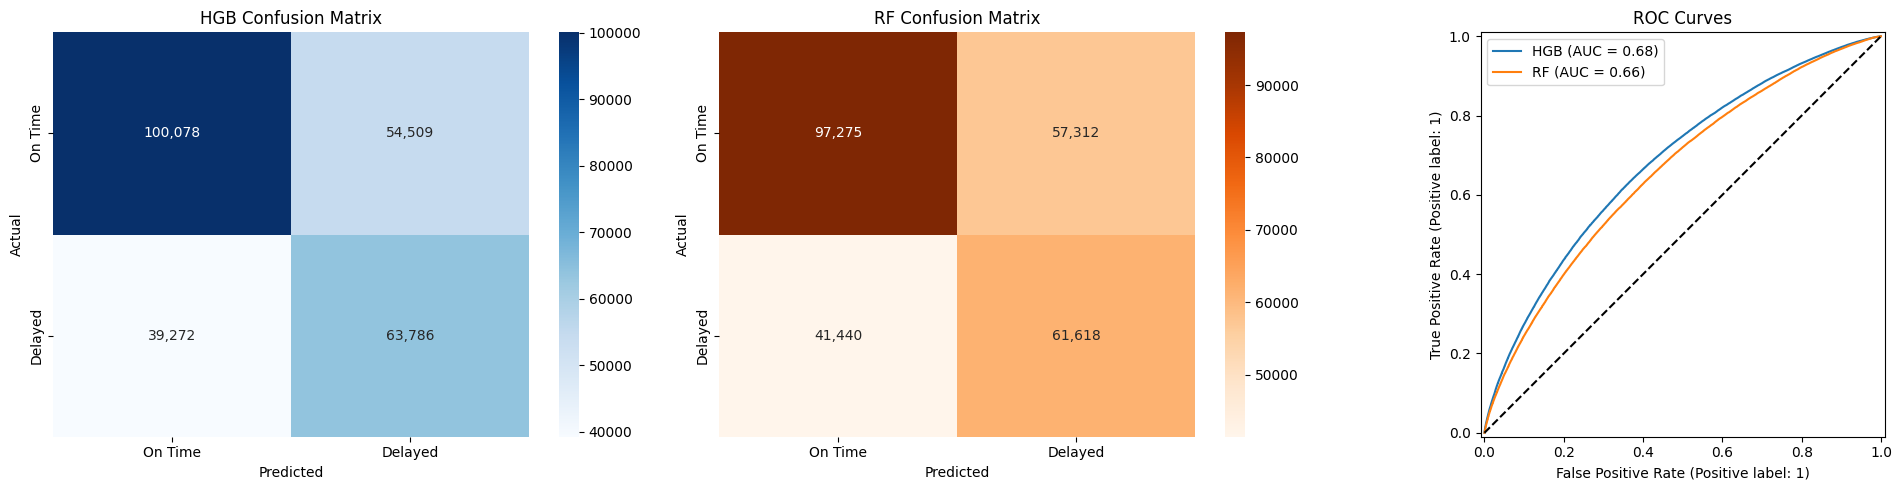

In [14]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm_hgb = confusion_matrix(y_test, y_pred_hgb)
sns.heatmap(cm_hgb, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['On Time', 'Delayed'], yticklabels=['On Time', 'Delayed'])
axes[0].set_title('HGB Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt=',d', cmap='Oranges', ax=axes[1],
            xticklabels=['On Time', 'Delayed'], yticklabels=['On Time', 'Delayed'])
axes[1].set_title('RF Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

RocCurveDisplay.from_estimator(hgb_clf, X_test.values, y_test, ax=axes[2], name='HGB')
RocCurveDisplay.from_estimator(rf_clf, X_test.values, y_test, ax=axes[2], name='RF')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title('ROC Curves')
axes[2].legend()

plt.tight_layout()
plt.show()

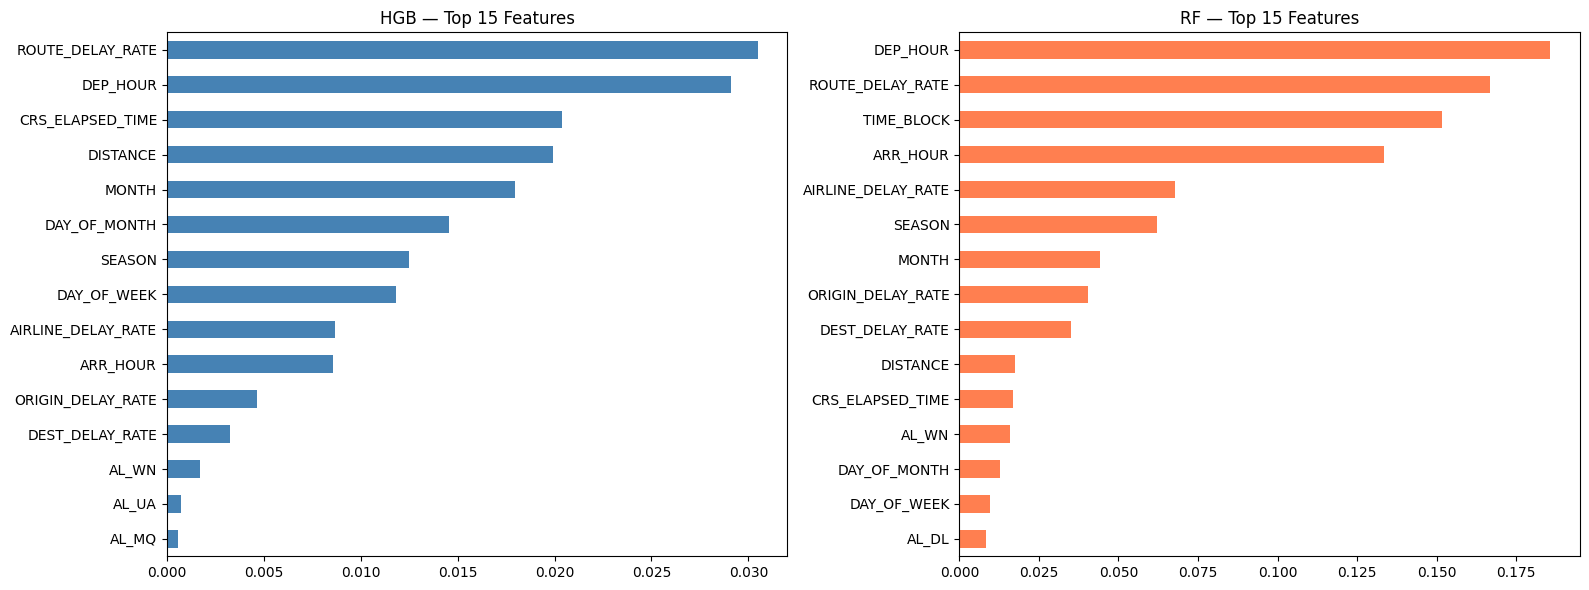

In [15]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# HGB — permutation importance
perm_hgb = permutation_importance(hgb_clf, X_test.values, y_test.values,
                                   n_repeats=5, random_state=42, n_jobs=1)
feat_imp_hgb = pd.Series(perm_hgb.importances_mean, index=X_train.columns).sort_values()
feat_imp_hgb.tail(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('HGB — Top 15 Features')

# RF
feat_imp_rf = pd.Series(rf_clf.feature_importances_, index=X_train.columns).sort_values()
feat_imp_rf.tail(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('RF — Top 15 Features')

plt.tight_layout()
plt.show()

In [16]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score

mlflow.set_experiment("flight_delay_v2")

with mlflow.start_run(run_name="HGB_preflight"):
    mlflow.log_param("model", "HistGradientBoosting")
    mlflow.log_param("max_iter", 300)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("balance_method", "undersample_60_40 + sample_weight")
    mlflow.log_param("scenario", "pre-flight")
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_hgb))
    mlflow.log_metric("f1_delayed", f1_score(y_test, y_pred_hgb))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, hgb_clf.predict_proba(X_test.values)[:,1]))
    mlflow.sklearn.log_model(hgb_clf, "model")
    print("✅ HGB logged")

with mlflow.start_run(run_name="RF_preflight"):
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("balance_method", "undersample_60_40 + class_weight")
    mlflow.log_param("scenario", "pre-flight")
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_rf))
    mlflow.log_metric("f1_delayed", f1_score(y_test, y_pred_rf))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, rf_clf.predict_proba(X_test.values)[:,1]))
    mlflow.sklearn.log_model(rf_clf, "model")
    print("✅ RF logged")

2026/02/24 13:30:24 INFO mlflow.tracking.fluent: Experiment with name 'flight_delay_v2' does not exist. Creating a new experiment.
2026/02/24 13:30:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/24 13:30:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ HGB logged


2026/02/24 13:30:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/24 13:30:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ RF logged


In [17]:
import joblib

joblib.dump(hgb_clf, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')
print("✅ Model, scaler, and feature names saved")

✅ Model, scaler, and feature names saved


In [18]:
import mlflow

experiment = mlflow.get_experiment_by_name("flight_delay_v2")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

print("="*60)
print("MLFLOW EXPERIMENT: flight_delay_v2")
print("="*60)
print(f"\nTotal runs: {len(runs)}\n")

display_cols = ['tags.mlflow.runName', 'params.model', 'params.balance_method',
                'metrics.accuracy', 'metrics.f1_delayed', 'metrics.roc_auc']

print(runs[display_cols].to_string(index=False))

MLFLOW EXPERIMENT: flight_delay_v2

Total runs: 2

tags.mlflow.runName         params.model             params.balance_method  metrics.accuracy  metrics.f1_delayed  metrics.roc_auc
       RF_preflight         RandomForest  undersample_60_40 + class_weight          0.616713            0.555147         0.659491
      HGB_preflight HistGradientBoosting undersample_60_40 + sample_weight          0.636007            0.576328         0.682771


In [19]:
import os

os.makedirs('api', exist_ok=True)
print("✅ api/ folder created")

# Verify saved files exist
for f in ['best_model.pkl', 'scaler.pkl', 'feature_names.pkl']:
    print(f"  {f}: {'✅' if os.path.exists(f) else '❌ MISSING'}")

✅ api/ folder created
  best_model.pkl: ✅
  scaler.pkl: ✅
  feature_names.pkl: ✅


In [20]:
%%writefile api/app.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np
import pandas as pd

# Load model, scaler, feature names
model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_names = joblib.load("feature_names.pkl")

app = FastAPI(title="Flight Delay Prediction API", version="1.0")

# =============================================
# Input schema
# =============================================
class FlightInput(BaseModel):
    airline_code: str         # e.g. "UA", "DL", "AA"
    origin: str               # e.g. "LAX"
    dest: str                 # e.g. "JFK"
    crs_elapsed_time: float   # scheduled flight duration (min)
    distance: float           # miles
    dep_hour: int             # 0-23
    arr_hour: int             # 0-23
    month: int                # 1-12
    day_of_week: int          # 0=Mon, 6=Sun
    day_of_month: int         # 1-31
    is_weekend: int           # 0 or 1
    season: int               # 1=winter, 2=spring, 3=summer, 4=fall
    time_block: int           # 0=night, 1=morning, 2=afternoon, 3=evening
    is_busy_origin: int       # 0 or 1
    route_delay_rate: float   # historical delay rate for this route
    airline_delay_rate: float # historical delay rate for this airline
    origin_delay_rate: float  # historical delay rate for origin airport
    dest_delay_rate: float    # historical delay rate for dest airport

# =============================================
# Health check
# =============================================
@app.get("/health")
def health():
    return {"status": "healthy", "model": "HistGradientBoosting", "version": "1.0"}

# =============================================
# Single prediction
# =============================================
@app.post("/predict")
def predict(flight: FlightInput):
    # Build feature vector
    data = {
        'CRS_ELAPSED_TIME': flight.crs_elapsed_time,
        'DISTANCE': flight.distance,
        'ROUTE_DELAY_RATE': flight.route_delay_rate,
        'AIRLINE_DELAY_RATE': flight.airline_delay_rate,
        'ORIGIN_DELAY_RATE': flight.origin_delay_rate,
        'DEST_DELAY_RATE': flight.dest_delay_rate,
        'DEP_HOUR': flight.dep_hour,
        'ARR_HOUR': flight.arr_hour,
        'MONTH': flight.month,
        'DAY_OF_WEEK': flight.day_of_week,
        'DAY_OF_MONTH': flight.day_of_month,
        'IS_WEEKEND': flight.is_weekend,
        'SEASON': flight.season,
        'TIME_BLOCK': flight.time_block,
        'IS_BUSY_ORIGIN': flight.is_busy_origin,
    }

    # One-hot encode airline
    for col in feature_names:
        if col.startswith('AL_'):
            airline = col.replace('AL_', '')
            data[col] = 1 if flight.airline_code == airline else 0

    # Create DataFrame with correct column order
    df = pd.DataFrame([data])[feature_names]

    # Scale numeric features
    numeric_features = ['CRS_ELAPSED_TIME', 'DISTANCE', 'ROUTE_DELAY_RATE',
                        'AIRLINE_DELAY_RATE', 'ORIGIN_DELAY_RATE', 'DEST_DELAY_RATE']
    df[numeric_features] = scaler.transform(df[numeric_features])

    # Predict
    prediction = model.predict(df.values)[0]
    probability = model.predict_proba(df.values)[0]

    return {
        "prediction": "DELAYED" if prediction == 1 else "ON TIME",
        "delay_probability": round(float(probability[1]), 4),
        "on_time_probability": round(float(probability[0]), 4),
        "flight": f"{flight.airline_code} {flight.origin} → {flight.dest}"
    }

# =============================================
# Batch prediction
# =============================================
@app.post("/predict/batch")
def predict_batch(flights: list[FlightInput]):
    results = [predict(f) for f in flights]
    return {"predictions": results, "count": len(results)}

Writing api/app.py


In [21]:
!pip install fastapi uvicorn -q

In [22]:
# Quick test without starting the server
import sys
sys.path.insert(0, '.')

from api.app import predict, FlightInput

# Test flight: United, LAX to JFK, evening, summer
test_flight = FlightInput(
    airline_code="UA",
    origin="LAX",
    dest="JFK",
    crs_elapsed_time=320,
    distance=2475,
    dep_hour=18,
    arr_hour=23,
    month=7,
    day_of_week=4,       # Friday
    day_of_month=18,
    is_weekend=0,
    season=3,            # Summer
    time_block=3,        # Evening
    is_busy_origin=1,    # LAX is busy
    route_delay_rate=0.22,
    airline_delay_rate=0.19,
    origin_delay_rate=0.20,
    dest_delay_rate=0.21
)

result = predict(test_flight)
print("="*40)
print("TEST PREDICTION")
print("="*40)
print(f"Flight: {result['flight']}")
print(f"Prediction: {result['prediction']}")
print(f"Delay probability: {result['delay_probability']:.1%}")
print(f"On-time probability: {result['on_time_probability']:.1%}")

TEST PREDICTION
Flight: UA LAX → JFK
Prediction: DELAYED
Delay probability: 78.0%
On-time probability: 22.0%


In [24]:
import os, shutil

os.makedirs('api', exist_ok=True)

# Copy model files
for f in ['best_model.pkl', 'scaler.pkl', 'feature_names.pkl']:
    if os.path.exists(f):
        shutil.copy(f, f'api/{f}')
        print(f"✅ Copied {f}")
    else:
        print(f"❌ Missing {f}")

print(f"\nWorking directory: {os.getcwd()}")
print(f"api/ contents: {os.listdir('api')}")

✅ Copied best_model.pkl
✅ Copied scaler.pkl
✅ Copied feature_names.pkl

Working directory: C:\Users\pc
api/ contents: ['app.py', 'best_model.pkl', 'feature_names.pkl', 'scaler.pkl', '__pycache__']


In [25]:
html_content = '''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Flight Delay Predictor</title>
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; font-family: 'Segoe UI', sans-serif; }
        body { background: #0f172a; color: #e2e8f0; min-height: 100vh; display: flex; justify-content: center; align-items: center; }
        .container { background: #1e293b; padding: 40px; border-radius: 16px; width: 500px; box-shadow: 0 20px 60px rgba(0,0,0,0.5); }
        h1 { text-align: center; margin-bottom: 8px; font-size: 24px; }
        .subtitle { text-align: center; color: #94a3b8; margin-bottom: 30px; font-size: 14px; }
        .row { display: flex; gap: 12px; margin-bottom: 16px; }
        .field { flex: 1; }
        label { display: block; font-size: 12px; color: #94a3b8; margin-bottom: 4px; }
        input, select { width: 100%; padding: 10px; border: 1px solid #334155; border-radius: 8px; background: #0f172a; color: #e2e8f0; font-size: 14px; }
        input:focus, select:focus { outline: none; border-color: #3b82f6; }
        button { width: 100%; padding: 14px; background: #3b82f6; color: white; border: none; border-radius: 8px; font-size: 16px; font-weight: 600; cursor: pointer; margin-top: 10px; }
        button:hover { background: #2563eb; }
        .result { margin-top: 24px; padding: 20px; border-radius: 12px; text-align: center; display: none; }
        .delayed { background: #991b1b; border: 1px solid #dc2626; }
        .ontime { background: #166534; border: 1px solid #22c55e; }
        .prediction-text { font-size: 28px; font-weight: 700; }
        .probability { font-size: 16px; margin-top: 8px; }
        .flight-info { font-size: 14px; color: #94a3b8; margin-top: 4px; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Flight Delay Predictor</h1>
        <p class="subtitle">Pre-flight delay prediction using ML</p>
        <div class="row">
            <div class="field">
                <label>Airline</label>
                <select id="airline">
                    <option value="UA">United (UA)</option>
                    <option value="DL">Delta (DL)</option>
                    <option value="AA">American (AA)</option>
                    <option value="WN">Southwest (WN)</option>
                    <option value="B6">JetBlue (B6)</option>
                    <option value="NK">Spirit (NK)</option>
                    <option value="F9">Frontier (F9)</option>
                    <option value="AS">Alaska (AS)</option>
                </select>
            </div>
            <div class="field">
                <label>Month</label>
                <select id="month">
                    <option value="1">January</option><option value="2">February</option>
                    <option value="3">March</option><option value="4">April</option>
                    <option value="5">May</option><option value="6">June</option>
                    <option value="7" selected>July</option><option value="8">August</option>
                    <option value="9">September</option><option value="10">October</option>
                    <option value="11">November</option><option value="12">December</option>
                </select>
            </div>
        </div>
        <div class="row">
            <div class="field">
                <label>Origin Airport</label>
                <input type="text" id="origin" placeholder="e.g. LAX" value="LAX" maxlength="3">
            </div>
            <div class="field">
                <label>Destination Airport</label>
                <input type="text" id="dest" placeholder="e.g. JFK" value="JFK" maxlength="3">
            </div>
        </div>
        <div class="row">
            <div class="field">
                <label>Departure Hour (0-23)</label>
                <input type="number" id="dep_hour" value="18" min="0" max="23">
            </div>
            <div class="field">
                <label>Distance (miles)</label>
                <input type="number" id="distance" value="2475">
            </div>
        </div>
        <div class="row">
            <div class="field">
                <label>Flight Duration (min)</label>
                <input type="number" id="duration" value="320">
            </div>
            <div class="field">
                <label>Day of Week</label>
                <select id="dow">
                    <option value="0">Monday</option><option value="1">Tuesday</option>
                    <option value="2">Wednesday</option><option value="3">Thursday</option>
                    <option value="4" selected>Friday</option><option value="5">Saturday</option>
                    <option value="6">Sunday</option>
                </select>
            </div>
        </div>
        <button onclick="predictDelay()">Predict Delay</button>
        <div class="result" id="result">
            <div class="prediction-text" id="predText"></div>
            <div class="probability" id="predProb"></div>
            <div class="flight-info" id="predFlight"></div>
        </div>
    </div>
    <script>
        async function predictDelay() {
            const month = parseInt(document.getElementById('month').value);
            const dow = parseInt(document.getElementById('dow').value);
            const depHour = parseInt(document.getElementById('dep_hour').value);
            const season = month <= 2 || month == 12 ? 1 : month <= 5 ? 2 : month <= 8 ? 3 : 4;
            const timeBlock = depHour <= 6 ? 0 : depHour <= 12 ? 1 : depHour <= 18 ? 2 : 3;
            const isWeekend = dow >= 5 ? 1 : 0;
            const payload = {
                airline_code: document.getElementById('airline').value,
                origin: document.getElementById('origin').value.toUpperCase(),
                dest: document.getElementById('dest').value.toUpperCase(),
                crs_elapsed_time: parseFloat(document.getElementById('duration').value),
                distance: parseFloat(document.getElementById('distance').value),
                dep_hour: depHour,
                arr_hour: (depHour + Math.floor(parseInt(document.getElementById('duration').value) / 60)) % 24,
                month: month,
                day_of_week: dow,
                day_of_month: 15,
                is_weekend: isWeekend,
                season: season,
                time_block: timeBlock,
                is_busy_origin: ["ATL","DFW","DEN","ORD","LAX","CLT","MCO","LAS","PHX","MIA"].includes(document.getElementById('origin').value.toUpperCase()) ? 1 : 0,
                route_delay_rate: 0.18,
                airline_delay_rate: 0.18,
                origin_delay_rate: 0.18,
                dest_delay_rate: 0.18
            };
            try {
                const response = await fetch('http://localhost:8000/predict', {
                    method: 'POST',
                    headers: {'Content-Type': 'application/json'},
                    body: JSON.stringify(payload)
                });
                const data = await response.json();
                const resultDiv = document.getElementById('result');
                resultDiv.style.display = 'block';
                resultDiv.className = data.prediction === 'DELAYED' ? 'result delayed' : 'result ontime';
                document.getElementById('predText').textContent = data.prediction === 'DELAYED' ? 'LIKELY DELAYED' : 'ON TIME';
                document.getElementById('predProb').textContent = 'Delay probability: ' + (data.delay_probability * 100).toFixed(1) + '%';
                document.getElementById('predFlight').textContent = data.flight;
            } catch (e) {
                alert('API Error: Make sure the server is running');
            }
        }
    </script>
</body>
</html>'''

with open('api/index.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print("✅ index.html created")
print(f"api/ contents: {os.listdir('api')}")

✅ index.html created
api/ contents: ['app.py', 'best_model.pkl', 'feature_names.pkl', 'index.html', 'scaler.pkl', '__pycache__']


In [26]:
app_code = '''from fastapi import FastAPI
from fastapi.responses import FileResponse
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import joblib
import numpy as np
import pandas as pd

model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_names = joblib.load("feature_names.pkl")

app = FastAPI(title="Flight Delay Prediction API", version="1.0")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

class FlightInput(BaseModel):
    airline_code: str
    origin: str
    dest: str
    crs_elapsed_time: float
    distance: float
    dep_hour: int
    arr_hour: int
    month: int
    day_of_week: int
    day_of_month: int
    is_weekend: int
    season: int
    time_block: int
    is_busy_origin: int
    route_delay_rate: float
    airline_delay_rate: float
    origin_delay_rate: float
    dest_delay_rate: float

@app.get("/")
def serve_frontend():
    return FileResponse("index.html")

@app.get("/health")
def health():
    return {"status": "healthy", "model": "HistGradientBoosting", "version": "1.0"}

@app.post("/predict")
def predict(flight: FlightInput):
    data = {
        "CRS_ELAPSED_TIME": flight.crs_elapsed_time,
        "DISTANCE": flight.distance,
        "ROUTE_DELAY_RATE": flight.route_delay_rate,
        "AIRLINE_DELAY_RATE": flight.airline_delay_rate,
        "ORIGIN_DELAY_RATE": flight.origin_delay_rate,
        "DEST_DELAY_RATE": flight.dest_delay_rate,
        "DEP_HOUR": flight.dep_hour,
        "ARR_HOUR": flight.arr_hour,
        "MONTH": flight.month,
        "DAY_OF_WEEK": flight.day_of_week,
        "DAY_OF_MONTH": flight.day_of_month,
        "IS_WEEKEND": flight.is_weekend,
        "SEASON": flight.season,
        "TIME_BLOCK": flight.time_block,
        "IS_BUSY_ORIGIN": flight.is_busy_origin,
    }
    for col in feature_names:
        if col.startswith("AL_"):
            airline = col.replace("AL_", "")
            data[col] = 1 if flight.airline_code == airline else 0

    df = pd.DataFrame([data])[feature_names]
    numeric_features = ["CRS_ELAPSED_TIME", "DISTANCE", "ROUTE_DELAY_RATE",
                        "AIRLINE_DELAY_RATE", "ORIGIN_DELAY_RATE", "DEST_DELAY_RATE"]
    df[numeric_features] = scaler.transform(df[numeric_features])

    prediction = model.predict(df.values)[0]
    probability = model.predict_proba(df.values)[0]

    return {
        "prediction": "DELAYED" if prediction == 1 else "ON TIME",
        "delay_probability": round(float(probability[1]), 4),
        "on_time_probability": round(float(probability[0]), 4),
        "flight": f"{flight.airline_code} {flight.origin} > {flight.dest}"
    }

@app.post("/predict/batch")
def predict_batch(flights: list[FlightInput]):
    results = [predict(f) for f in flights]
    return {"predictions": results, "count": len(results)}
'''

with open('api/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✅ app.py updated")

✅ app.py updated


In [27]:
import subprocess, time, requests

# Start server
process = subprocess.Popen(
    ['python', '-m', 'uvicorn', 'app:app', '--host', '0.0.0.0', '--port', '8000'],
    cwd='api'
)
time.sleep(5)

try:
    r = requests.get("http://localhost:8000/health")
    print(f"✅ Server running: {r.json()}")
    print(f"\n🌐 Open in browser: http://localhost:8000")
    print(f"📄 API docs: http://localhost:8000/docs")
except Exception as e:
    print(f"❌ Error: {e}")

✅ Server running: {'status': 'healthy', 'model': 'HistGradientBoosting', 'version': '1.0'}

🌐 Open in browser: http://localhost:8000
📄 API docs: http://localhost:8000/docs
